In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm

from src.agents.cart_a2c import A2CCartAgent
from src.plots import plot_durations


In [ ]:
LR = 1e-4
num_episodes = 6000

In [3]:
env = gym.make("CartPole-v1", render_mode=None)
agent = A2CCartAgent(env=env, learning_rate=LR)

# Training loop

Complete


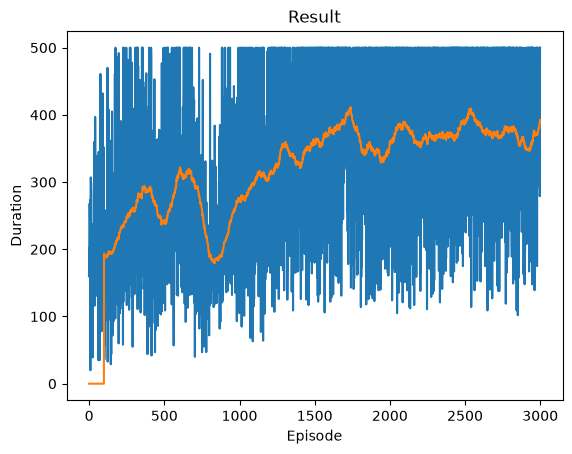

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
episode_durations = []
for _ in range(num_episodes):
    state, _ = env.reset()

    done = False

    probs = []
    rewards = []
    states = []

    running_batch = []
    
    t = 0
    while not done:
        states.append(state)

        action, prob = agent.get_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        probs.append(prob)
        rewards.append(reward)

        if agent.update_critic(running_batch):
            running_batch = []

        running_batch.append((state, action, reward, next_state, done))
        state = next_state
        t += 1



    states_t = torch.tensor(np.array(states), dtype=torch.float32) 

    critiques = agent.critic(states_t).squeeze(-1)

    agent.update(rewards, probs, critiques)

    episode_durations.append(t)
    plot_durations(episode_durations)


print('Complete')
plot_durations(episode_durations, show_result=True)
plt.ioff()
plt.show()

In [9]:
test_env = gym.make("CartPole-v1", render_mode=None)
test_agent = A2CCartAgent(env, 0, 0)

test_agent.policy.load_state_dict(agent.policy.state_dict())

test_reward = []

for _ in tqdm(range(1000)):
    state, _ = test_env.reset()
    done = False
    total_reward = 0
    while not done:
        action = test_agent.act(state)
        next_state, reward, terminated, truncated, _ = test_env.step(action)

        done = terminated or truncated
        state = next_state
        total_reward += reward

    test_reward.append(total_reward)

print("avg: ", np.average(test_reward))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:17<00:00, 56.64it/s]

avg:  498.345


In [10]:
from safetensors.torch import save_file

if np.average(test_reward) > 490.0:
    print(f"Saved {np.average(test_reward)}")
    save_file(agent.policy.state_dict(), f"./data/a2c_e{num_episodes}.safetensors")

Saved 498.345
